# Milestones 6 & 7 — Evaluation and Explainability

**Project:** Intelligent Diabetic Retinopathy Detection and Progress Monitoring Using AI/ML

---

> ### ⚠️ Academic prototype — not a medical device
> Screening-support demonstration only. Not clinically validated. Not for diagnosis.

---

## The one rule for this notebook

The **test split is evaluated once**, here, after all model selection is finished.
Everything up to now — which epoch to checkpoint, which architecture looked best —
was decided on the validation split.

If you evaluate on test, change something, and evaluate again, your reported numbers
are optimistically biased and you would have to disclose that in your report. So:
run this, write down what it says, and move on.

## Sections

| | |
|---|---|
| 1–2 | Setup, confirm the runs are comparable |
| 3 | Evaluate all three architectures on the test split |
| 4 | Comparison table — **this is your results table** |
| 5 | Confusion matrices |
| 6 | Per-class recall and ROC curves |
| 7 | Error analysis — why QWK is high when accuracy isn't |
| 8 | Grad-CAM: successes and failures |
| 9 | Sentences for your report, generated from your own numbers |


## 1. Setup

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
assert (PROJECT_ROOT / "src").is_dir(), f"src/ not found under {PROJECT_ROOT}"

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.utils.config import class_names, ensure_dirs, get_path, load_config
from src.utils.seed import set_seed

cfg = load_config()
set_seed(cfg["project"]["seed"])

# Notebooks on Windows can hang when the DataLoader spawns worker processes.
# Inference over 550 cached images is fast enough single-threaded.
cfg["training"]["num_workers"] = 0

CLASS_NAMES     = class_names(cfg)
EXPERIMENTS_DIR = get_path(cfg, "experiments_dir")
ensure_dirs(cfg, "reports_dir", "figures_dir")
REPORTS_DIR     = get_path(cfg, "reports_dir")
FIGURES_DIR     = get_path(cfg, "figures_dir")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SPLIT  = "test"          # change to "val" for a dry run that doesn't burn test

plt.rcParams["figure.dpi"] = 110
print("Device :", DEVICE)
print("Split  :", SPLIT)
print("Classes:", CLASS_NAMES)

Device : cuda
Split  : test
Classes: ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']


## 2. Which runs are we comparing?

A run counts as finished when it has a `best.pt`. Smoke tests are excluded automatically.

The **split fingerprint** check matters: if two runs show different fingerprints they
were trained on different data partitions, and comparing them proves nothing.

In [2]:
from src.models.evaluate import find_runs

runs = find_runs(EXPERIMENTS_DIR)
if not runs:
    print("No finished runs found in", EXPERIMENTS_DIR)
    print("Each run needs a best.pt. Train first.")
else:
    rows = []
    for run_dir in runs:
        mpath = run_dir / "metrics_val.json"
        entry = {"run": run_dir.name}
        if mpath.is_file():
            data = json.loads(mpath.read_text())
            s, m = data["summary"], data["val_metrics"]
            entry.update(backbone=s["backbone"], val_QWK=m.get("qwk"),
                         best_epoch=s["best_epoch"], epochs_run=s["epochs_run"],
                         minutes=s["total_minutes"], fingerprint=s["split_fingerprint"])
        rows.append(entry)
    summary = pd.DataFrame(rows)
    display(summary)

    if "fingerprint" in summary:
        prints = summary["fingerprint"].dropna().unique()
        if len(prints) > 1:
            print("\nWARNING: runs used DIFFERENT splits", prints)
            print("They are NOT comparable. Re-train on a single split.")
        else:
            print(f"\nAll runs share split fingerprint {prints[0]} - comparison is valid.")

,run,backbone,val_QWK,best_epoch,epochs_run,minutes,fingerprint
0,densenet121_weighted,densenet121,0.8992,8,13,10.07,415bcc1c575a
1,effnetb3_weighted,efficientnet_b3,0.8938,3,8,6.55,415bcc1c575a
2,resnet50_weighted,resnet50,0.8949,12,17,9.68,415bcc1c575a



All runs share split fingerprint 415bcc1c575a - comparison is valid.


## 3. Evaluate on the held-out test split

This is the one-shot evaluation. Each model runs over the 550 test images it has never
seen, and the results are written to `experiments/<run>/metrics_test.json`.

In [3]:
from src.models.evaluate import evaluate_run
from src.models.metrics import summarise_for_console

all_metrics = []
for run_dir in runs:
    print(f"\n=== {run_dir.name} ===")
    try:
        m = evaluate_run(run_dir, cfg, DEVICE, split=SPLIT)
        all_metrics.append(m)
        print(summarise_for_console(m))
    except Exception as exc:
        print(f"  FAILED: {type(exc).__name__}: {exc}")

print(f"\nEvaluated {len(all_metrics)} model(s) on the {SPLIT} split.")


=== densenet121_weighted ===
  samples            : 550
  QWK                : 0.8910   <-- headline metric
  accuracy           : 0.7964
  balanced accuracy  : 0.6370
  macro F1           : 0.6412
  macro ROC-AUC      : 0.9311
  per-class recall   :
      0 No DR              recall 0.971  (n=271)
      1 Mild               recall 0.518  (n=56)
      2 Moderate           recall 0.727  (n=150)
      3 Severe             recall 0.379  (n=29)
      4 Proliferative DR   recall 0.591  (n=44)

=== effnetb3_weighted ===
  samples            : 550
  QWK                : 0.8583   <-- headline metric
  accuracy           : 0.7800
  balanced accuracy  : 0.6428
  macro F1           : 0.6201
  macro ROC-AUC      : 0.9211
  per-class recall   :
      0 No DR              recall 0.971  (n=271)
      1 Mild               recall 0.554  (n=56)
      2 Moderate           recall 0.660  (n=150)
      3 Severe             recall 0.621  (n=29)
      4 Proliferative DR   recall 0.409  (n=44)

=== resnet50_w

## 4. The results table

This is what goes in your report. Note the columns beyond QWK — `balanced_acc` and the
per-class recalls are where the class imbalance shows up, and an examiner will look there.

In [4]:
from src.models.evaluate import comparison_table

if all_metrics:
    comparison = comparison_table(all_metrics)
    display(comparison)

    path = REPORTS_DIR / f"m6_{SPLIT}_comparison.csv"
    comparison.to_csv(path, index=False)
    print(f"Saved -> {path.relative_to(PROJECT_ROOT)}")

    best = max(all_metrics, key=lambda m: m["qwk"])
    BEST_TAG = best.get("backbone", "best")
    print(f"\nBest by {SPLIT} QWK: {BEST_TAG} ({best['qwk']:.4f})")

    spread = comparison["QWK"].max() - comparison["QWK"].min()
    print(f"Spread across architectures: {spread:.4f} QWK")
    if spread < 0.03:
        print("\nThat spread is small. With 550 test images this is probably within noise -")
        print("say 'achieved the highest QWK' in your report, not 'is superior'.")

,backbone,run,QWK,accuracy,balanced_acc,F1_macro,AUC_macro,best_epoch,recall_0,recall_1,recall_2,recall_3,recall_4
0,densenet121,densenet121_weighted,0.8910,0.7964,0.6370,0.6412,0.9311,8,0.9705,0.5179,0.7267,0.3793,0.5909
1,resnet50,resnet50_weighted,0.8773,0.7964,0.6017,0.6142,0.9324,12,0.9742,0.4643,0.7933,0.3448,0.4318
2,efficientnet_b3,effnetb3_weighted,0.8583,0.7800,0.6428,0.6201,0.9211,3,0.9705,0.5536,0.6600,0.6207,0.4091


Saved -> reports\m6_test_comparison.csv

Best by test QWK: densenet121 (0.8910)
Spread across architectures: 0.0327 QWK


Saved -> reports\figures\m6_model_comparison.png


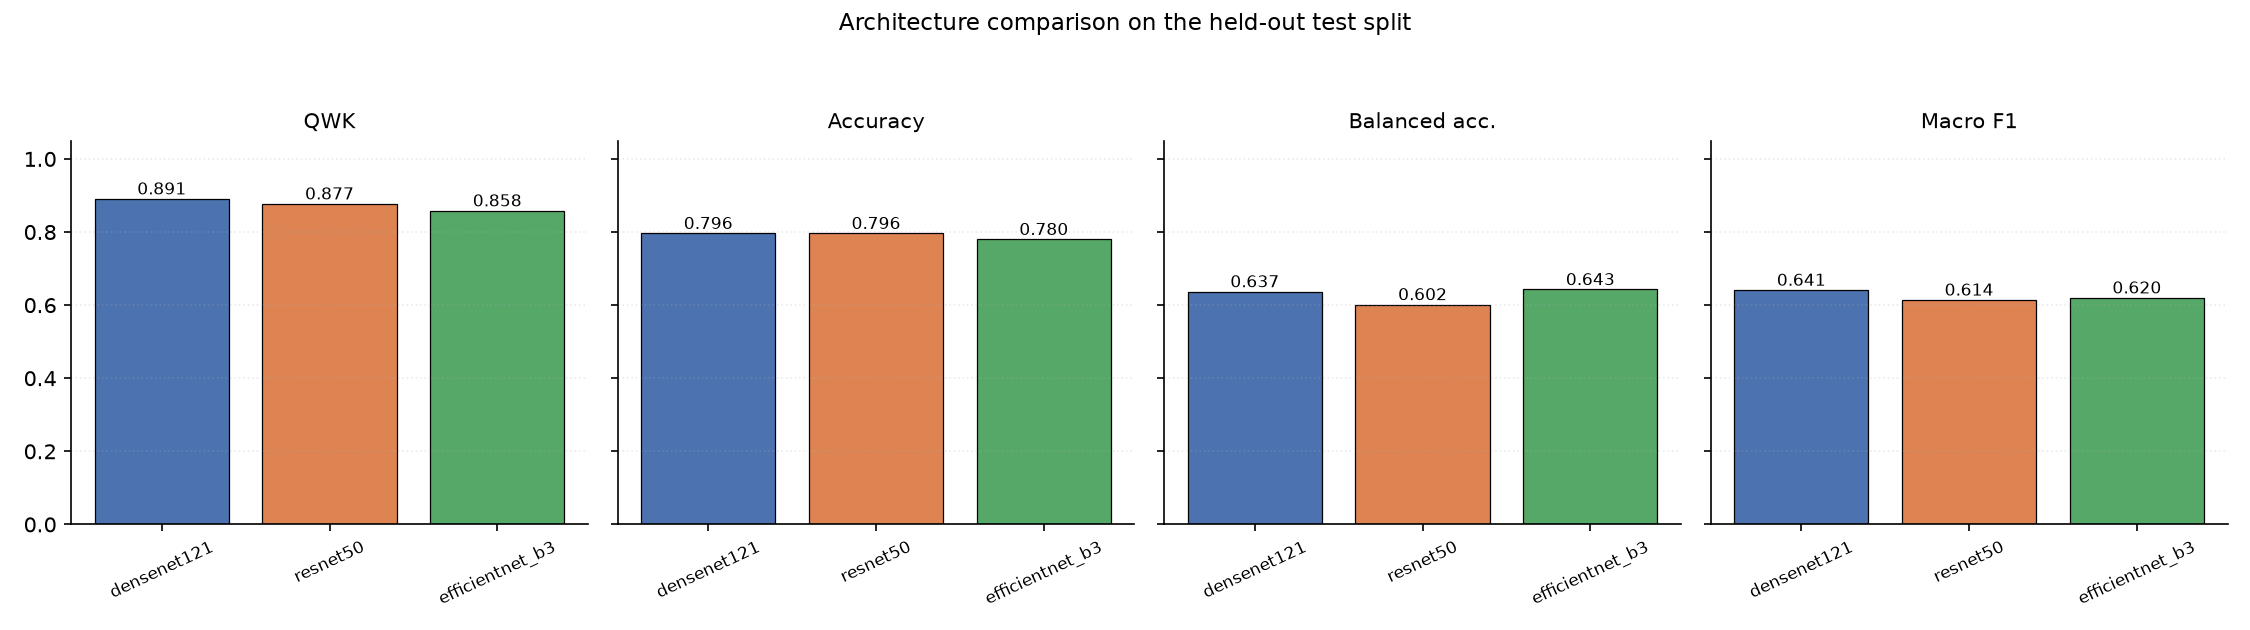

In [5]:
# Headline comparison figure
from src.models.figures import plot_model_comparison

if all_metrics:
    out = FIGURES_DIR / "m6_model_comparison.png"
    plot_model_comparison(comparison, out)
    print(f"Saved -> {out.relative_to(PROJECT_ROOT)}")
    from IPython.display import Image, display as ipy_display
    ipy_display(Image(filename=str(out)))

## 4b. Are the differences real? Bootstrap confidence intervals

Your three architectures will land close together. Before writing "X is the best model",
measure whether that gap survives sampling noise.

**Method.** Resample the test set with replacement 1,000 times, recompute the metric each
time, and take the 2.5th and 97.5th percentiles. That interval answers: *if I had drawn a
different sample of 550 patients from the same population, what range of scores would I
have seen?*

**Comparing two models.** Checking whether two separate intervals overlap is needlessly
conservative, because both models saw the *same* images. A **paired** bootstrap resamples
the indices once per iteration and scores both models on that same resample, so shared
sample difficulty cancels out. What's left is the distribution of the *difference*.

If a pairwise interval includes zero, the two models are indistinguishable on this test
set — and saying so is a stronger result than a ranking you can't defend.

In [6]:
from src.models.bootstrap import (bootstrap_all_runs, pairwise_comparison,
                                  plot_forest, interpret)

N_BOOT = 1000        # 1,000 is standard; 10,000 is smoother but slower

if all_metrics:
    boot_runs = {m.get("backbone", m.get("run_name")): (m["_y_true"], m["_y_pred"])
                 for m in all_metrics}

    ci_table = bootstrap_all_runs(boot_runs, n_boot=N_BOOT, seed=cfg["project"]["seed"])
    display(ci_table[["model", "qwk", "qwk_ci", "accuracy", "accuracy_ci",
                      "balanced_accuracy", "balanced_accuracy_ci"]])

    ci_table.to_csv(REPORTS_DIR / f"m6_{SPLIT}_confidence_intervals.csv", index=False)

    width = ci_table["qwk_hi"].iloc[0] - ci_table["qwk_lo"].iloc[0]
    spread = ci_table["qwk"].max() - ci_table["qwk"].min()
    print(f"\nCI width for the best model : {width:.4f} QWK")
    print(f"Spread across architectures : {spread:.4f} QWK")
    print(f"Ratio                       : the interval is {width/max(spread,1e-9):.1f}x "
          f"the gap between models")

,model,qwk,qwk_ci,accuracy,accuracy_ci,balanced_accuracy,balanced_accuracy_ci
0,densenet121,0.8910,"[0.865, 0.916]",0.7964,"[0.762, 0.829]",0.6370,"[0.582, 0.689]"
1,resnet50,0.8773,"[0.847, 0.904]",0.7964,"[0.765, 0.831]",0.6017,"[0.547, 0.656]"
2,efficientnet_b3,0.8583,"[0.824, 0.888]",0.7800,"[0.744, 0.815]",0.6428,"[0.586, 0.693]"



CI width for the best model : 0.0517 QWK
Spread across architectures : 0.0327 QWK
Ratio                       : the interval is 1.6x the gap between models


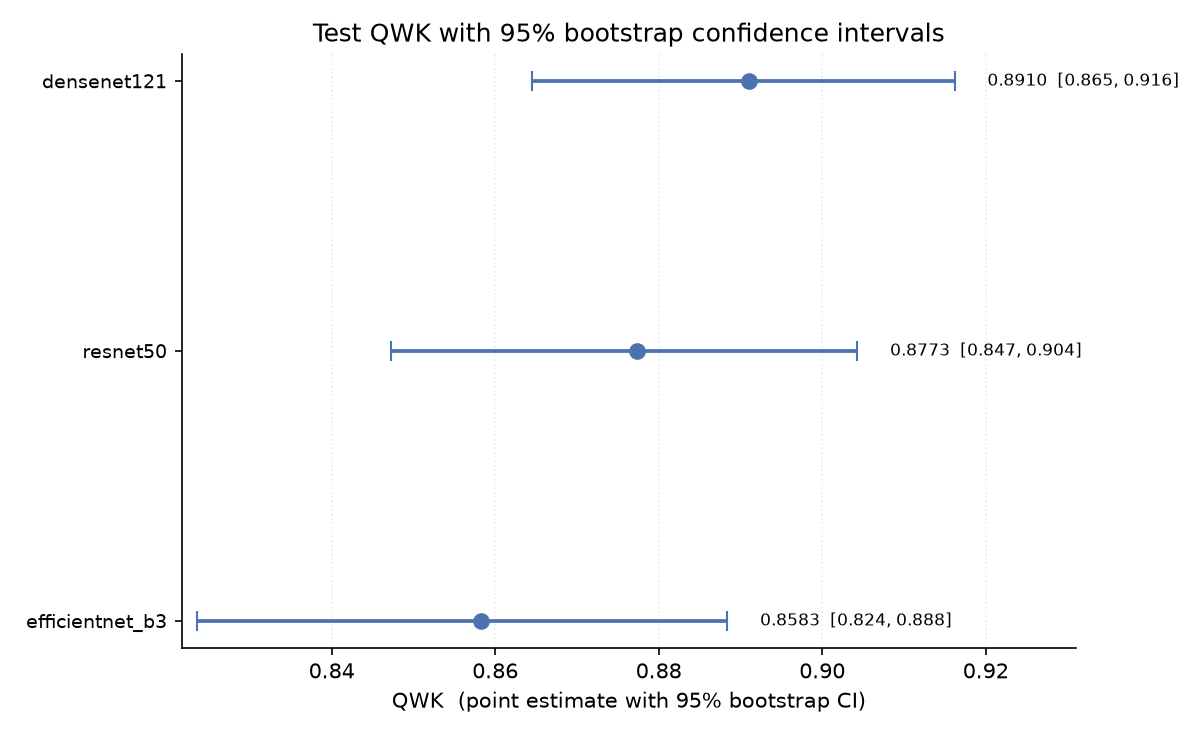

Overlapping bars = the models are not distinguishable on this test set.


In [7]:
if all_metrics:
    out = FIGURES_DIR / f"m6_qwk_confidence_intervals_{SPLIT}.png"
    plot_forest(ci_table, "qwk", out,
                title=f"{SPLIT.capitalize()} QWK with 95% bootstrap confidence intervals")
    ipy_display(Image(filename=str(out)))
    print("Overlapping bars = the models are not distinguishable on this test set.")

In [8]:
if all_metrics and len(all_metrics) > 1:
    pairs = pairwise_comparison(boot_runs, metric="qwk", n_boot=N_BOOT,
                                seed=cfg["project"]["seed"])
    display(pairs)
    pairs.to_csv(REPORTS_DIR / f"m6_{SPLIT}_pairwise.csv", index=False)

    print("\nHow to read this:")
    print("  difference       - model A's QWK minus model B's, on the real test set")
    print("  ci_low / ci_high - 95% interval for that difference across 1,000 resamples")
    print("  prob_a_better    - fraction of resamples where A beat B (evidence strength,")
    print("                     NOT a p-value): 0.5 is a coin flip, 0.99 is convincing")
    print("  distinguishable  - True only if the interval excludes zero")

    print("\n" + "=" * 72)
    print("FOR YOUR REPORT:")
    print("=" * 72)
    print(interpret(ci_table, pairs, "qwk"))
    print("=" * 72)

,model_a,model_b,difference,ci_low,ci_high,prob_a_better,distinguishable
0,densenet121,efficientnet_b3,0.0327,0.0040,0.0647,0.991,True
1,densenet121,resnet50,0.0137,-0.0118,0.0398,0.846,False
2,efficientnet_b3,resnet50,-0.0190,-0.0492,0.0096,0.096,False



How to read this:
  difference       - model A's QWK minus model B's, on the real test set
  ci_low / ci_high - 95% interval for that difference across 1,000 resamples
  prob_a_better    - fraction of resamples where A beat B (evidence strength,
                     NOT a p-value): 0.5 is a coin flip, 0.99 is convincing
  distinguishable  - True only if the interval excludes zero

FOR YOUR REPORT:
densenet121 achieved the highest QWK at 0.8910 (95% CI [0.865, 0.916]). The spread across architectures was 0.0327 QWK. The difference between densenet121 and efficientnet_b3 (+0.0327, 95% CI [0.004, 0.065]) excludes zero, so these two are distinguishable on this test set.


### Why this matters for your viva

Without this section, your results table invites the question *"is that difference
meaningful?"* and you have no answer.

With it, you answer before being asked — and reporting a null result honestly
("no architecture is distinguishable on this evidence") demonstrates more statistical
literacy than claiming a 0.005 win.

There's a real finding underneath it too: if three architectures spanning 7M to 23M
parameters all perform the same, the bottleneck is the **2,562 training images**, not the
model. That points your Future Work section somewhere concrete — more data, or external
validation on EyePACS — rather than "try more architectures".

## 5. Confusion matrices

Both versions, always. The raw counts are dominated by class 0 and make the rare classes
invisible; the row-normalised version (each row = that class's recall) shows what is
actually happening to Severe and Mild.

Look for a **banded** matrix — most mass on and immediately beside the diagonal. That
banding is what a high QWK alongside a moderate accuracy looks like.

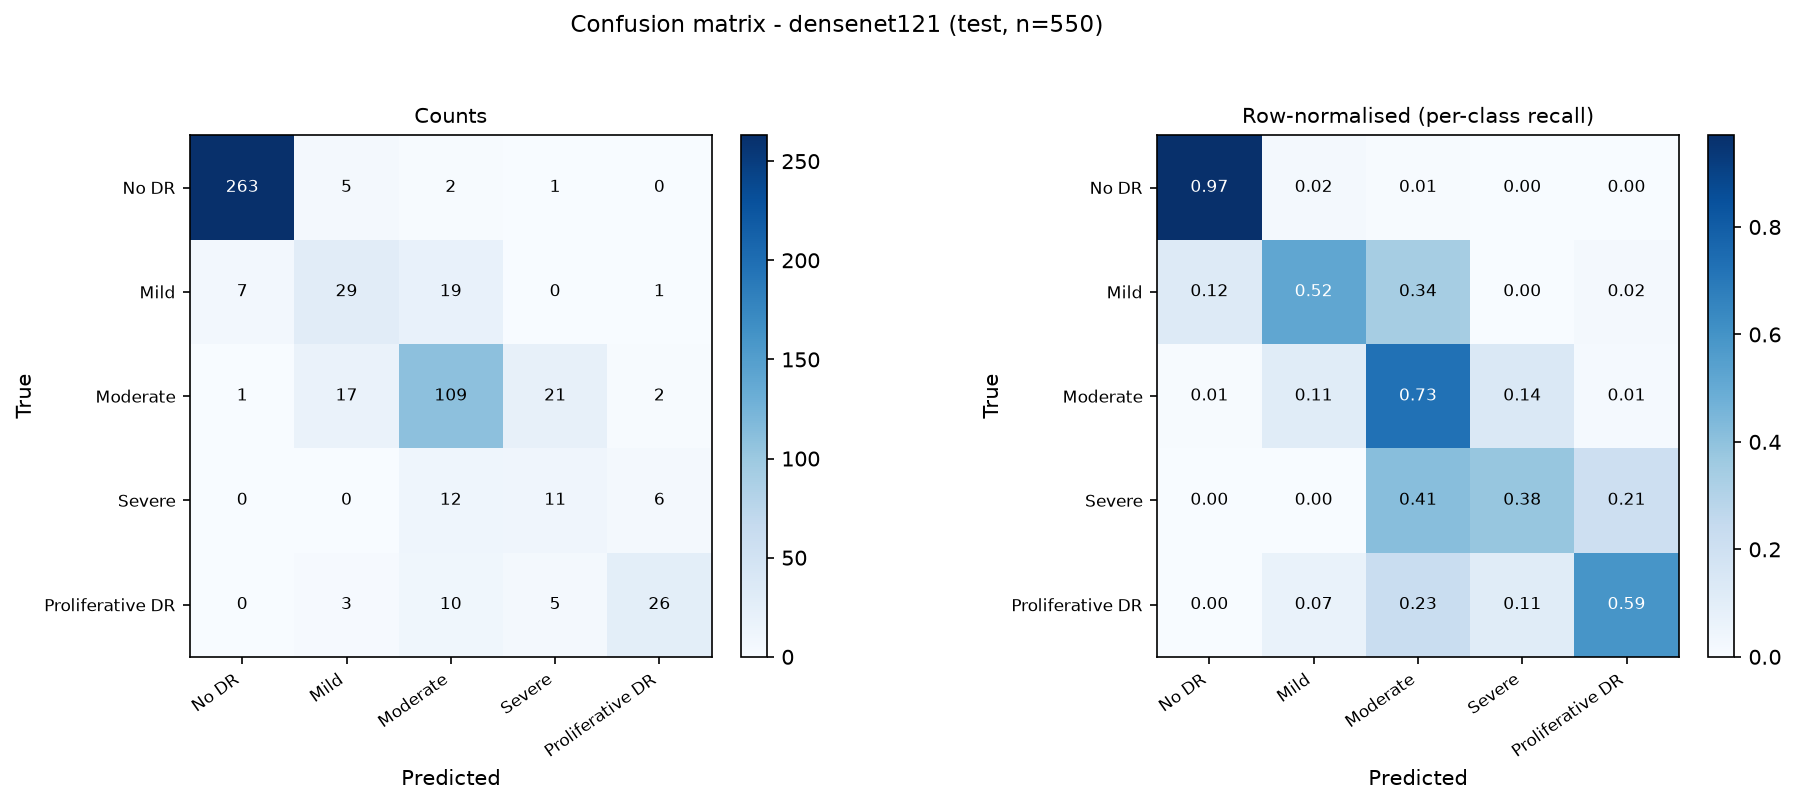

Off-diagonal mass immediately adjacent to the diagonal: 82.1% of all errors


In [9]:
from src.models.figures import plot_confusion_matrices
from IPython.display import Image, display as ipy_display

if all_metrics:
    out = FIGURES_DIR / f"m6_confusion_matrix_{BEST_TAG}.png"
    plot_confusion_matrices(best["confusion_matrix"], CLASS_NAMES, out,
                            title=f"Confusion matrix - {BEST_TAG} ({SPLIT}, n={best['n_samples']})")
    ipy_display(Image(filename=str(out)))

    cm = np.array(best["confusion_matrix"])
    print("Off-diagonal mass immediately adjacent to the diagonal:",
          f"{(np.trace(cm,1)+np.trace(cm,-1))/max(cm.sum()-np.trace(cm),1):.1%} of all errors")

## 6. Per-class performance and ROC

**Recall on classes 3 and 4 is the clinically important number.** Missing severe disease is
the dangerous error; calling a healthy eye mild is merely inconvenient. A macro average
hides that distinction, so report per-class recall explicitly.

,label,class_name,precision,recall,f1,support
0,0,No DR,0.9705,0.9705,0.9705,271
1,1,Mild,0.5370,0.5179,0.5273,56
2,2,Moderate,0.7171,0.7267,0.7219,150
3,3,Severe,0.2895,0.3793,0.3284,29
4,4,Proliferative DR,0.7429,0.5909,0.6582,44


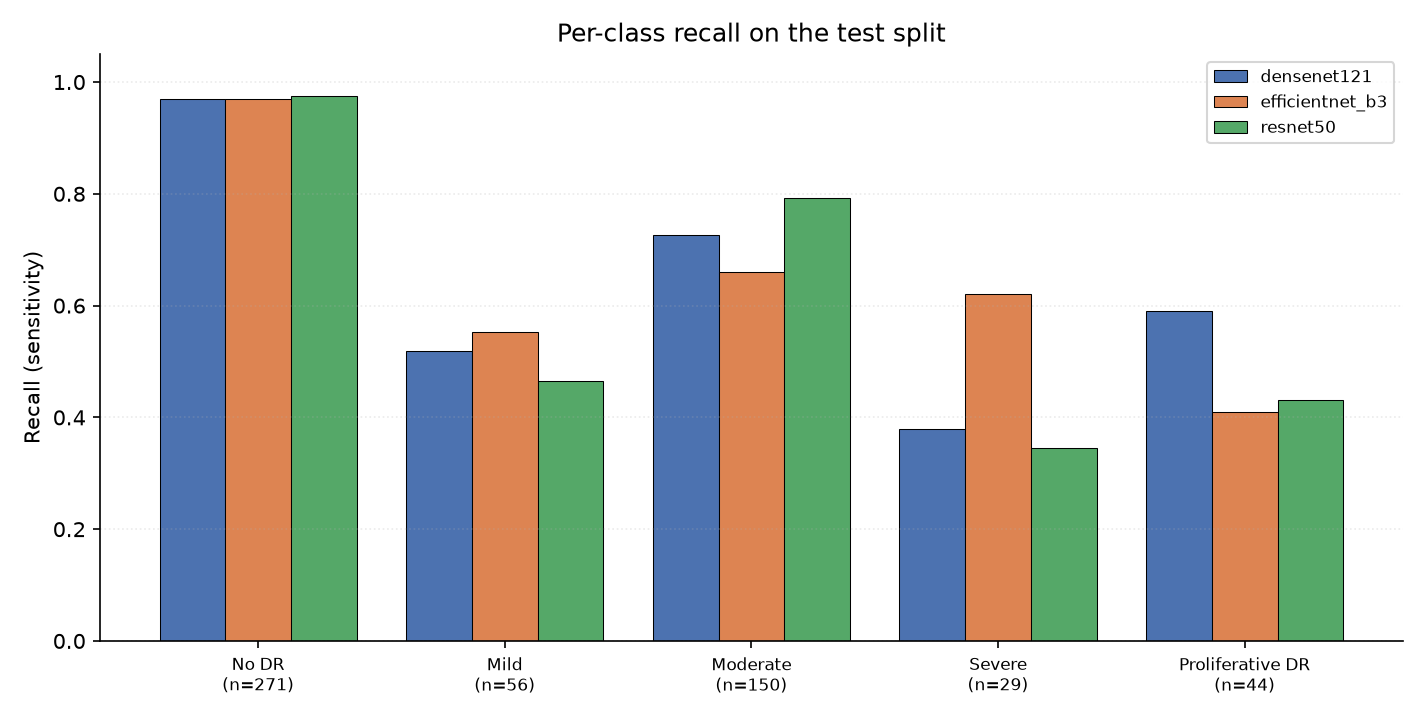

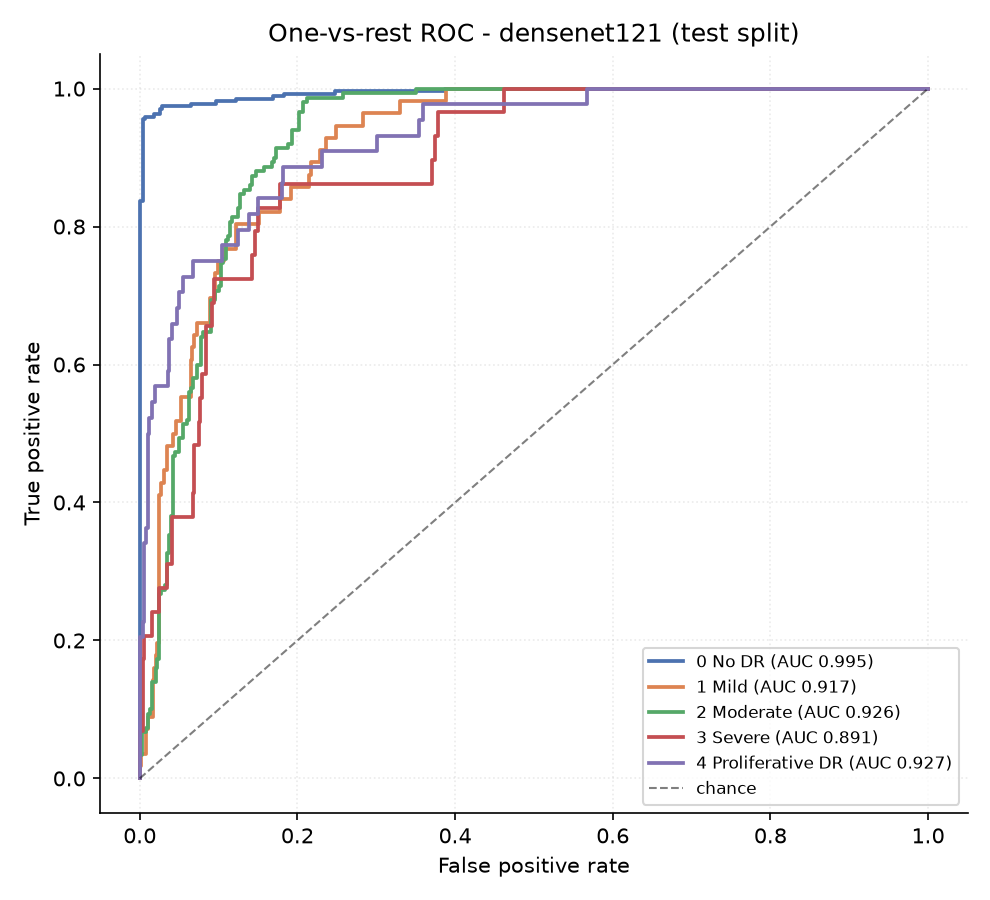

In [10]:
from src.models.figures import plot_per_class_recall, plot_roc_curves
from src.models.evaluate import per_class_table

if all_metrics:
    display(per_class_table(best))
    per_class_table(best).to_csv(REPORTS_DIR / f"m6_per_class_{BEST_TAG}.csv", index=False)

    out = FIGURES_DIR / "m6_per_class_recall.png"
    plot_per_class_recall(all_metrics, CLASS_NAMES, out)
    ipy_display(Image(filename=str(out)))

    out = FIGURES_DIR / f"m6_roc_curves_{BEST_TAG}.png"
    plot_roc_curves(best["_y_true"], best["_probabilities"], CLASS_NAMES, out,
                    title=f"One-vs-rest ROC - {BEST_TAG} ({SPLIT} split)")
    ipy_display(Image(filename=str(out)))

## 7. Error analysis — the argument for QWK

Because grading is ordinal, *how wrong* matters. This section quantifies it, and the
"within one grade" number is the single most useful statistic for your discussion section:
it explains why QWK sits high while plain accuracy looks unremarkable.

Exact grade match   : 79.6%   (= accuracy)
Within one grade    : 96.4%   <-- why QWK is high
Within two grades   : 99.1%
Mean absolute error : 0.249 grades
Error distances     : {0: 438, 1: 92, 2: 15, 3: 5, 4: 0}


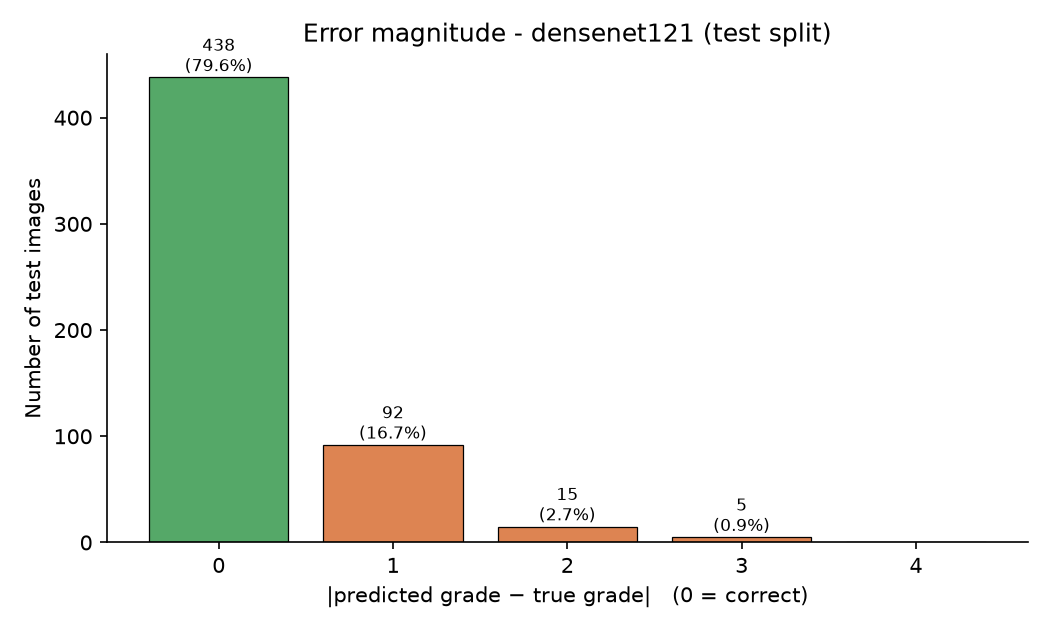


Worst mistakes (largest grade distance):


,id,true,pred,distance
0,fce93caa4758,4,1,3
1,eaa0dfbd5024,4,1,3
2,a8263d248523,0,3,3
3,8bed09514c3b,4,1,3
4,73881f55a3ec,1,4,3
5,e150935f66a6,2,0,2
6,cd54d022e37d,4,2,2
7,f03d3c4ce7fb,4,2,2
8,a688f20f8895,2,4,2
9,8f318a978844,4,2,2


In [11]:
from src.models.evaluate import error_analysis
from src.models.figures import plot_error_distance

if all_metrics:
    errors = error_analysis(best["_y_true"], best["_y_pred"], best["_ids"])

    print(f"Exact grade match   : {errors['exact_match_pct']:.1f}%   (= accuracy)")
    print(f"Within one grade    : {errors['within_one_pct']:.1f}%   <-- why QWK is high")
    print(f"Within two grades   : {errors['within_two_pct']:.1f}%")
    print(f"Mean absolute error : {errors['mean_abs_error']:.3f} grades")
    print(f"Error distances     : {errors['error_distance_counts']}")

    out = FIGURES_DIR / f"m6_error_distance_{BEST_TAG}.png"
    plot_error_distance(errors, out, title=f"Error magnitude - {BEST_TAG} ({SPLIT} split)")
    ipy_display(Image(filename=str(out)))

    print("\nWorst mistakes (largest grade distance):")
    display(pd.DataFrame(errors["worst_examples"]))

    (REPORTS_DIR / "m6_error_analysis.json").write_text(
        json.dumps({"best_model": BEST_TAG, **errors}, indent=2), encoding="utf-8")

## 8. Grad-CAM — does the model look at the right thing?

A five-way softmax is not evidence. A model can reach a decent QWK by keying on lens
flare, a watermark, or the black frame, and the score alone will never reveal it.

Grad-CAM (Selvaraju et al., 2017) highlights the pixels that drove the prediction:

1. Forward pass, keep the last conv layer's activations
2. Backward from the predicted class score, keep the gradients
3. Average each gradient channel spatially → one weight per feature map
4. Weighted sum, then ReLU (positive evidence only)
5. Upsample to image size

The map is coarse — roughly 10×10 upsampled to 300×300. It localises **regions**, not
individual microaneurysms. Say that in your report rather than overclaiming.

In [12]:
import subprocess

# Grad-CAM runs as a script: it needs gradients enabled and hooks attached, which is
# cleaner outside the notebook's execution model.
if all_metrics:
    best_run = [r for r in runs if r.name == best.get("run_name")]
    run_name = best_run[0].name if best_run else runs[0].name
    print(f"Run this in a terminal:\n   python -m scripts.m7_gradcam --run {run_name}\n")
    print("Then re-run the next cell to view the figures.")

Run this in a terminal:
   python -m scripts.m7_gradcam --run densenet121_weighted

Then re-run the next cell to view the figures.



=== m7_gradcam_correct.png ===


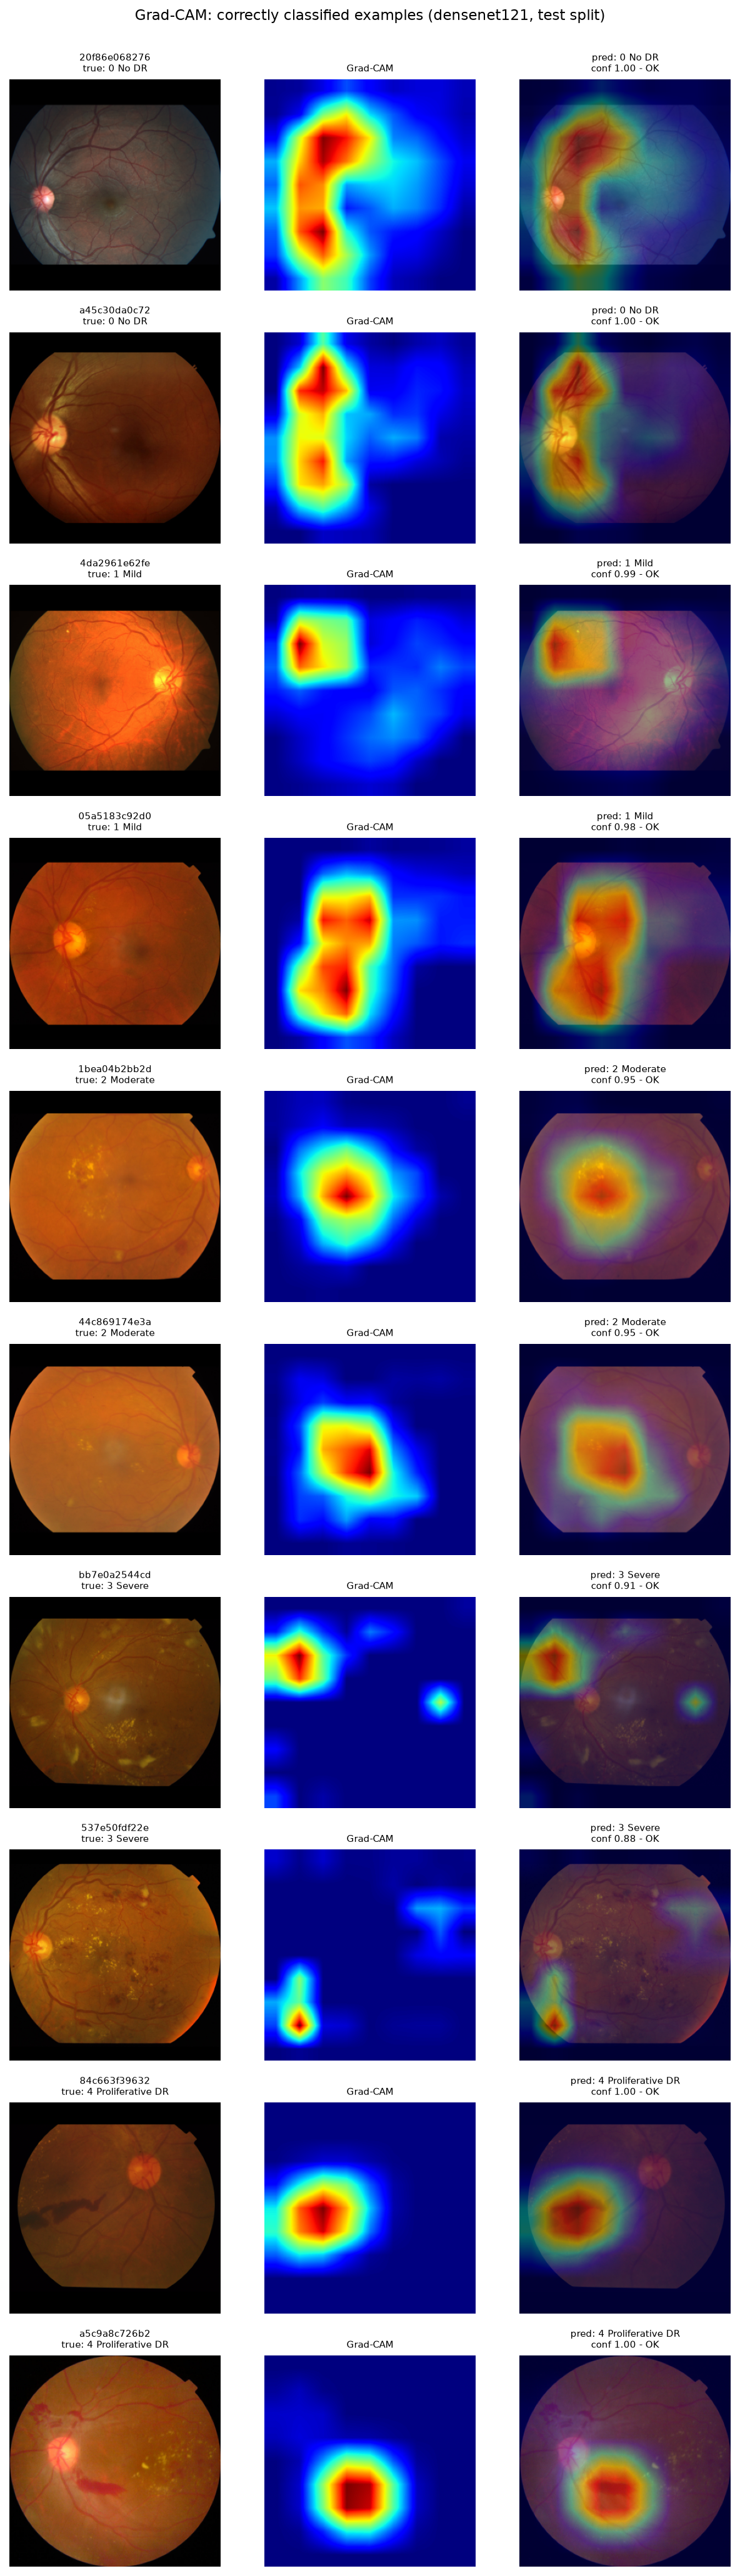


=== m7_gradcam_failures.png ===


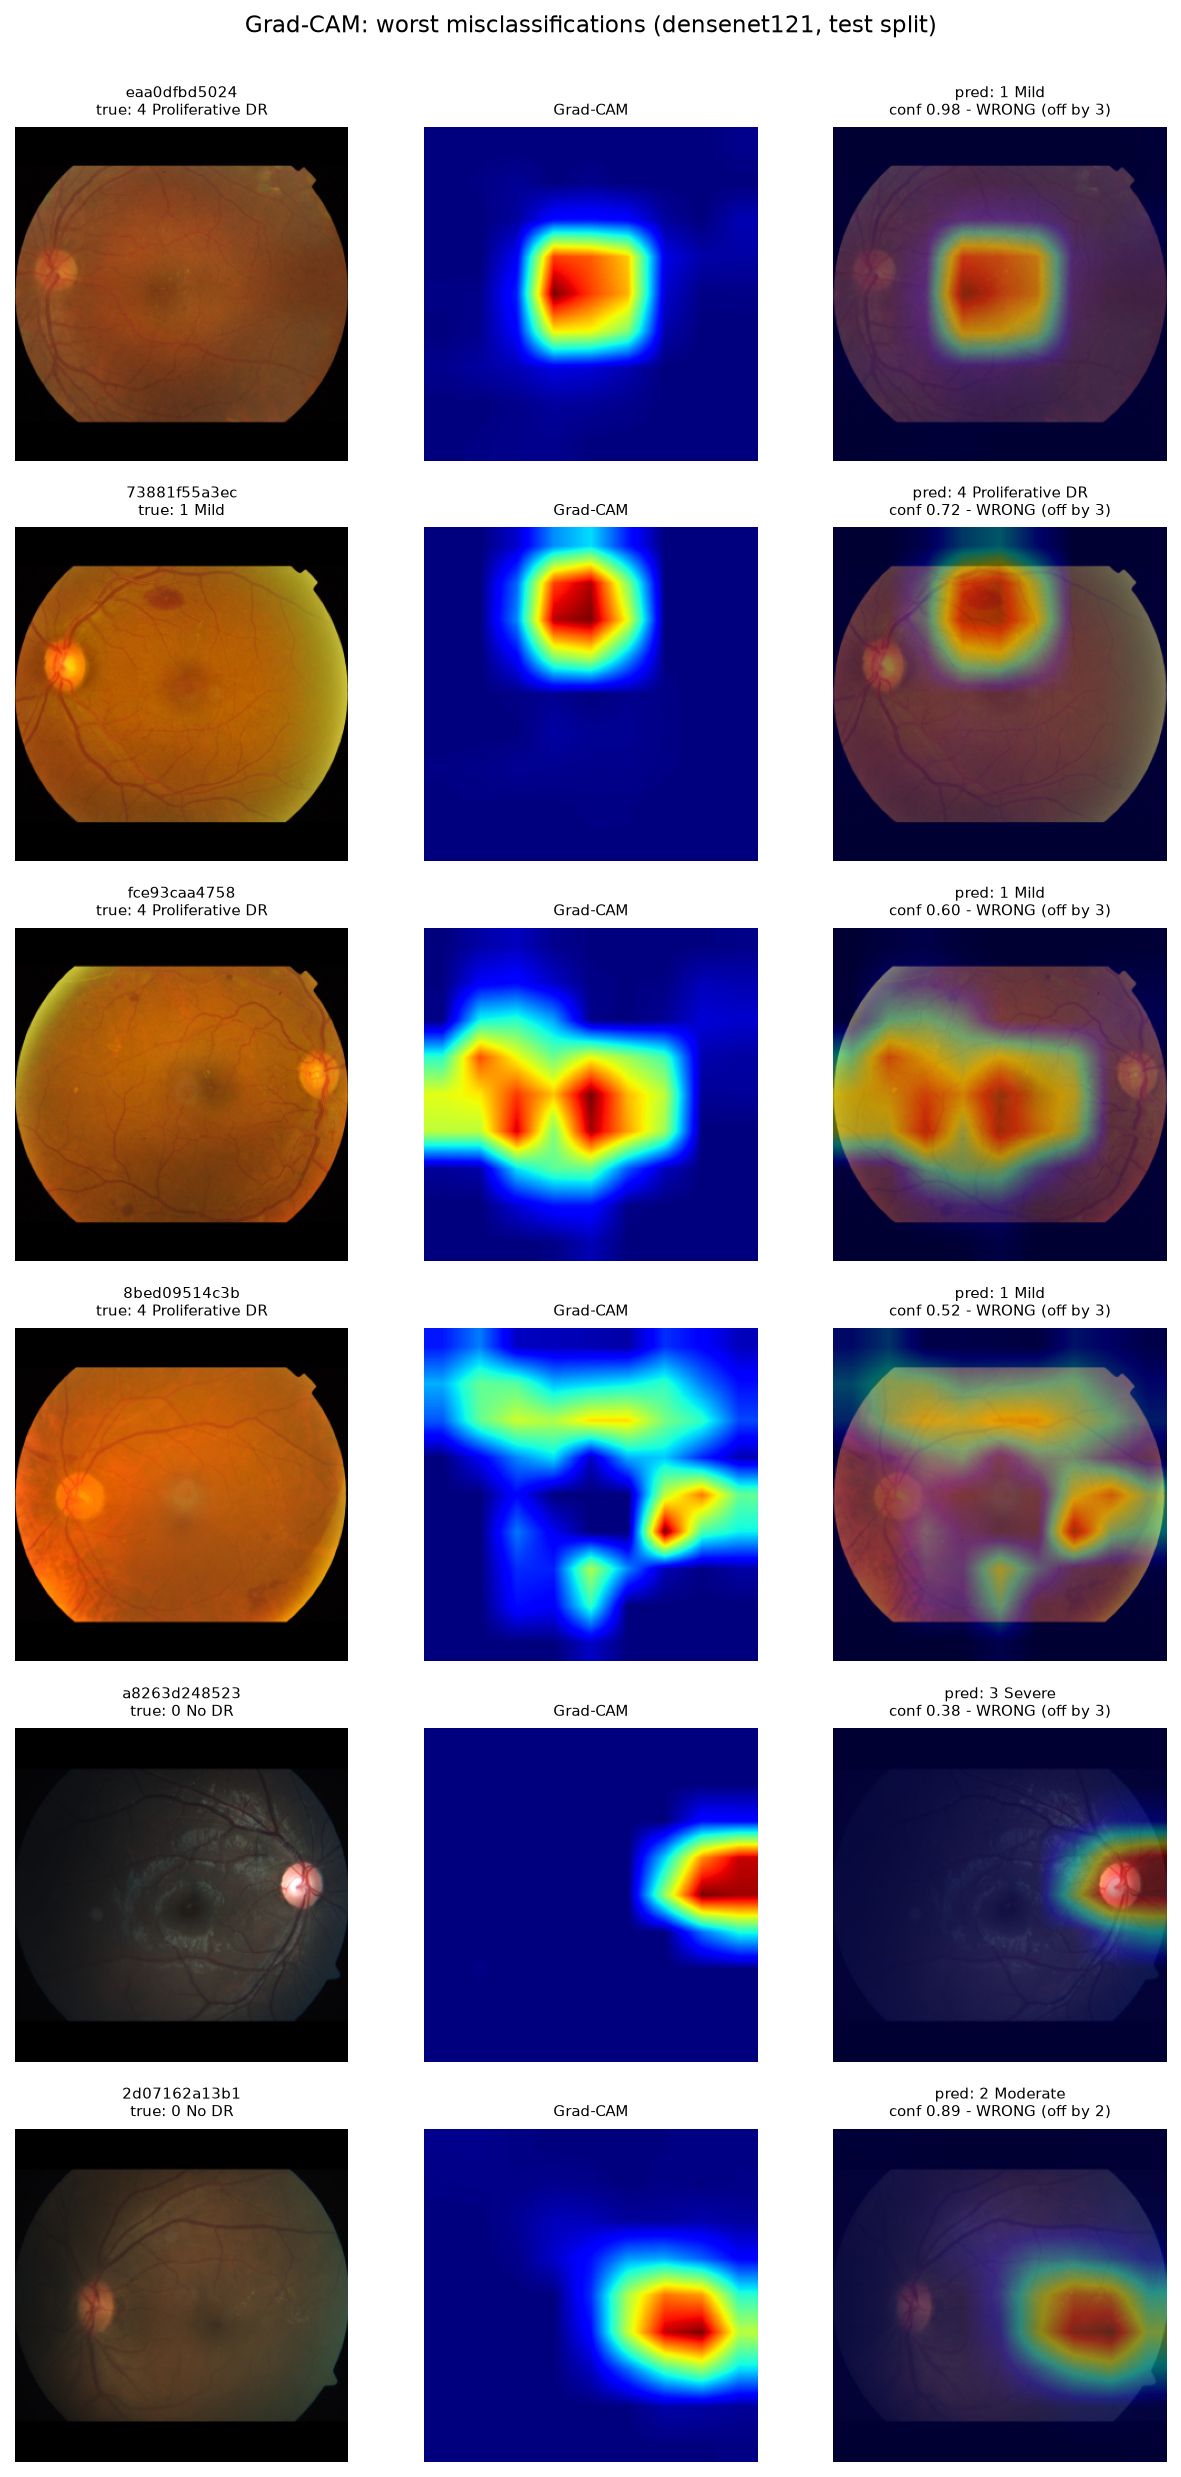

,id,true,pred,confidence,distance,cam_predicted,cam_confidence,hot_area_fraction,border_fraction,peak_value,mean_value,group
0,20f86e068276,0,0,0.999992,0,0,1.0000,0.2172,0.1705,1.0,0.3001,correct
1,a45c30da0c72,0,0,0.999988,0,0,1.0000,0.1554,0.1212,1.0,0.2134,correct
2,4da2961e62fe,1,1,0.991271,0,1,0.9913,0.0709,0.1304,1.0,0.1655,correct
3,05a5183c92d0,1,1,0.984862,0,1,0.9849,0.1980,0.0271,1.0,0.2379,correct
4,1bea04b2bb2d,2,2,0.947295,0,2,0.9474,0.0927,0.0000,1.0,0.1423,correct
5,44c869174e3a,2,2,0.945341,0,2,0.9453,0.1028,0.0000,1.0,0.1476,correct
6,bb7e0a2544cd,3,3,0.912258,0,3,0.9124,0.0508,0.5113,1.0,0.0763,correct
7,537e50fdf22e,3,3,0.880593,0,3,0.8807,0.0139,0.5028,1.0,0.0533,correct
8,84c663f39632,4,4,1.000000,0,4,1.0000,0.0900,0.1290,1.0,0.1157,correct
9,a5c9a8c726b2,4,4,1.000000,0,4,1.0000,0.0851,0.0000,1.0,0.1157,correct



Mean attention in the image border: 18.1%
Low - consistent with the model attending to the retina, not the frame.


In [15]:
# View the Grad-CAM figures once the script has produced them
for fname in ("m7_gradcam_correct.png", "m7_gradcam_failures.png"):
    path = FIGURES_DIR / fname
    if path.is_file():
        print(f"\n=== {fname} ===")
        ipy_display(Image(filename=str(path)))
    else:
        print(f"{fname} not found yet - run scripts.m7_gradcam first.")

stats_path = REPORTS_DIR / "m7_gradcam_stats.csv"
if stats_path.is_file():
    stats = pd.read_csv(stats_path)
    display(stats)
    border = stats["border_fraction"].mean()
    print(f"\nMean attention in the image border: {border:.1%}")
    if border > 0.35:
        print("HIGH - the model may be keying on the frame edge rather than pathology.")
        print("Report this honestly. It is a known failure mode of fundus classifiers,")
        print("and naming it yourself is far stronger than having it pointed out.")
    else:
        print("Low - consistent with the model attending to the retina, not the frame.")

### What to actually look for

Don't ask "is the heatmap pretty". Ask:

- **On correct Severe/Proliferative cases** — is the hot region on visible lesions
  (dark haemorrhage blots, pale exudates, neovascular tufts) or on the optic disc and
  vessels alone?
- **On failures** — did it attend to the wrong region, or to a plausible region and still
  grade it wrong? Those are different problems and worth distinguishing.
- **Anywhere** — is the heat sitting on the frame edge? That's the model cheating.

Write two or three sentences of honest observation. That paragraph is the whole point of
the explainability milestone.

## 9. Report sentences from your own numbers

Generated from what you just computed. Check each one, then paste into your report.

In [16]:
if all_metrics:
    n = best["n_samples"]
    print("=" * 72)
    print("RESULTS (paste into your report, then verify every number)")
    print("=" * 72)
    print(f"""
The three architectures were trained under identical conditions - the same
stratified split (fingerprint {best.get('split_fingerprint')}), the same 300x300
preprocessing, the same augmentation, the same weighted cross-entropy loss and
the same optimisation schedule - so that the only variable was the architecture.

On the held-out test split (n={n}), {BEST_TAG} achieved the highest Quadratic
Weighted Kappa at {best['qwk']:.4f}, with an accuracy of {best['accuracy']:.4f} and a
balanced accuracy of {best['balanced_accuracy']:.4f}. The gap between accuracy and
balanced accuracy reflects the class imbalance: a model can score well overall
while performing poorly on the rare severe grades.

Quadratic Weighted Kappa was adopted as the primary metric because diabetic
retinopathy grading is ordinal. A degenerate classifier predicting "No DR" for
every image would achieve roughly 49% accuracy on this dataset but a QWK of 0.
Error analysis supports this choice: {errors['within_one_pct']:.1f}% of test predictions
fell within one grade of the true label, with a mean absolute error of
{errors['mean_abs_error']:.3f} grades.

Per-class recall was """ + ", ".join(
        f"{pc['recall']:.3f} for {pc['class_name']} (n={pc['support']})"
        for pc in best["per_class"]) + f""".

LIMITATIONS: the model was trained and evaluated on a single dataset (APTOS 2019)
with no external validation, and the rarest class had only
{min(pc['support'] for pc in best['per_class'])} test samples, so its per-class
metrics carry wide uncertainty. No clinician reviewed the predictions. The system
is a screening-support prototype and is not suitable for clinical use.
""")
    print("=" * 72)

RESULTS (paste into your report, then verify every number)

The three architectures were trained under identical conditions - the same
stratified split (fingerprint 415bcc1c575a), the same 300x300
preprocessing, the same augmentation, the same weighted cross-entropy loss and
the same optimisation schedule - so that the only variable was the architecture.

On the held-out test split (n=550), densenet121 achieved the highest Quadratic
Weighted Kappa at 0.8910, with an accuracy of 0.7964 and a
balanced accuracy of 0.6370. The gap between accuracy and
balanced accuracy reflects the class imbalance: a model can score well overall
while performing poorly on the rare severe grades.

Quadratic Weighted Kappa was adopted as the primary metric because diabetic
retinopathy grading is ordinal. A degenerate classifier predicting "No DR" for
every image would achieve roughly 49% accuracy on this dataset but a QWK of 0.
Error analysis supports this choice: 96.4% of test predictions
fell within one gr

---

## Milestones 6 & 7 complete

```powershell
git add .
git commit -m "Milestones 6-7: test evaluation and Grad-CAM"
git tag m7
```

**Next: Milestone 8** — the SQLite database for patient visit records, then Milestone 9
(progression analysis) and Milestone 10 (the Streamlit app).

Send your mentor the comparison table from section 4 and the error analysis from section 7.